In [116]:
from plot_transit_time import transit_params, degg_list,extract_fit_params,extract_temperature,extract_histogram,extract_device

In [117]:
#!/usr/bin/env python

import os
import glob

import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator


import pandas as pd

import json

from pathlib import Path
home = str(Path.home())

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"
plt.rcParams.update({'font.size': 18})



In [118]:
pd.to_datetime(time, unit='s').strftime('%Y-%m-%d')

'2023-01-31'

In [119]:
plotFolder = home+"/research_ua/icecube/Upgrade/timing_calibration/plots/degg_transit"
degg_list = [f.path for f in os.scandir(home+"/research_ua/icecube/upgrade/timing_calibration/data/degg_transit/") if f.is_dir()]

In [120]:
#degg_list

In [121]:
def extract_time(json_file):
    with open(json_file, 'r') as f:
        data = json.load(f)
    return data["meas_time"]

In [122]:
def extract_pmt(json_file):
    with open(json_file, 'r') as f:
        data = json.load(f)
    return data["subdevice_uid"].split("_")[-1]

In [142]:
temp_limits = [-30,50]
file_list = []
for idegg in degg_list:
    ifiles = sorted(glob.glob(idegg+"/DEgg*"))
    file_list += ifiles
a_list = []
mu_list = []
sigma_list = []
chi2_list = []
pvalue_list = []
temp_list = []
doms_with_temp = []
hv_list = []
hv_data_file = "/Users/epaudel/research_ua/icecube/upgrade/degg_pmt_hv/scripts/degg_pmt_voltage.json"

with open(hv_data_file, 'r') as f:
    hv_data = json.load(f)

for ifile in file_list:
    a,mu,sigma,chi2,pvalue = extract_fit_params(ifile)
    pmt_name = extract_pmt(ifile)
    time = extract_time(ifile)
    time = str(pd.to_datetime(time, unit='s').strftime('%Y%m%d'))
    # print([ielt["meas_date"] for ielt in hv_data if ielt["pmt_name"]==pmt_name][0],str(time),[ielt["meas_date"] for ielt in hv_data if ielt["pmt_name"]==pmt_name][0]==str(time))
    hv = [float(ielt["voltage"][:-1]) for ielt in hv_data if ielt["pmt_name"]==pmt_name and str(ielt["meas_date"]) == str(time)]
    hv_value = hv[0] if len(hv) > 0 else None
    print(hv_value)
    # print(hv)
    if sigma > 40:
        print(f"sigma {sigma} in {ifile}")


    itemp = extract_temperature(ifile)
    idevice,isubdevice = extract_device(ifile)
    if itemp < -10:
        doms_with_temp.append(isubdevice)
    

    # if -10 <itemp < 10:
    #     print(ifile,itemp)
    # print(chi2,pvalue)
    # chi2,pvalue  = get_chi2(ifile)
    if mu > -500 and sigma < 45 and temp_limits[0]<=itemp<temp_limits[1] and hv_value is not None:
        # pmt_name = 
        mu_list.append(mu)
        sigma_list.append(sigma)
        chi2_list.append(chi2)
        a_list.append(a)
        temp_list.append(itemp)
        hv_list.append(hv_value)

1487.721591337639
None
1479.2654150581836
None
1515.9482752691779
1513.3856807834022
1527.237529804668
1527.237529804668
1608.4797028692647
1616.2880457454946
1610.3976577752192
1610.3976577752192
1541.4344682795822
None
None
1557.080522393903
None
None
1468.9617158615547
None
None
1529.5900125866312
None
None
1508.714404663203
None
1517.3595226335074
1512.5157127182554
None
1521.2428316309556
1416.414643342512
1413.1248834444727
1420.024343119337
1443.2580670101363
1435.3990979536636
1451.8249997928774
None
1624.4886367781332
None
1467.162304595682
None
1540.1453508605384
None
1462.2802621937926
1298.2953888220432
None
1312.8871734176603
1573.6866854199031
None
1581.997142854869
1496.0835526760652
1496.5879507510892
1510.3609076771784
1408.9069949937616
1414.7074866226344
1411.5402685013937
None
None
1439.6758164664777
None
None
1470.4859911226956
1492.4724673381388
1498.4025288502528
1495.131180788456
1549.549318073968
1550.7427819641712
1554.5967847516226
1620.1762489120267
1624.462

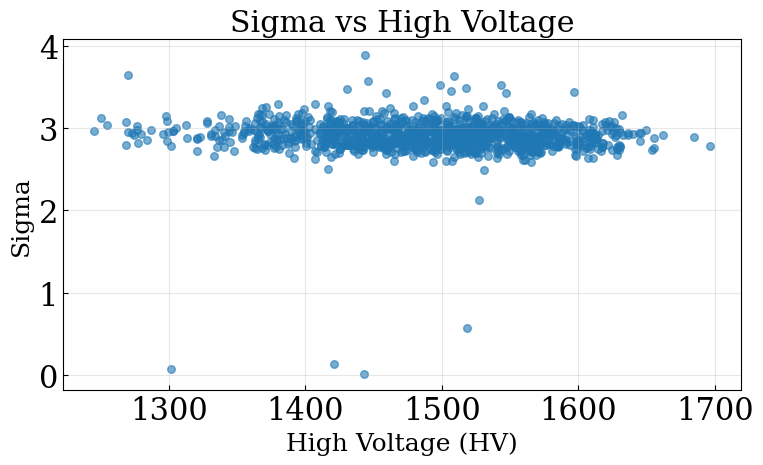

In [153]:
fig = plt.figure(figsize=(8,5))
gs = gridspec.GridSpec(nrows=1,ncols=1)
ax = fig.add_subplot(gs[0])
ax.scatter(hv_list, sigma_list, alpha=0.6, s=30)
ax.set_xlabel('High Voltage (HV)')
ax.set_ylabel('Sigma')
ax.set_title('Sigma vs High Voltage')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='both',which='both', direction='in', labelsize=22)
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
plt.tight_layout()
plt.savefig(f'{plotFolder}/degg_tts_vs_hv.png', dpi=300)
plt.show()

In [154]:
def get_tts(hv):
    return 2.454 - 0.001319 * (hv - 1500)

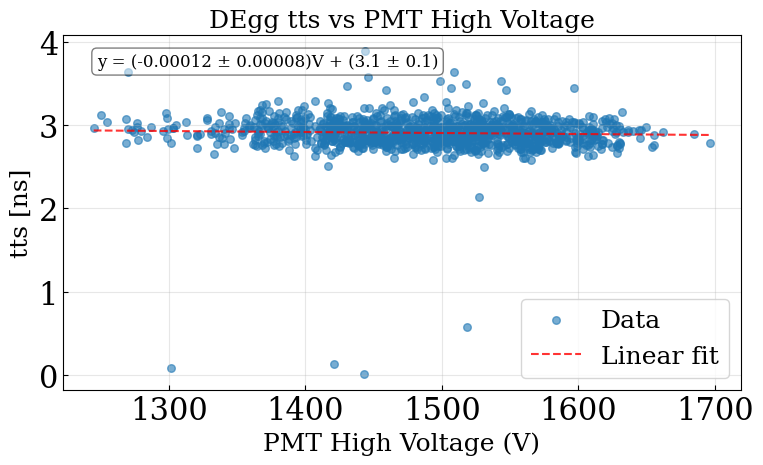

In [155]:
from scipy.optimize import curve_fit
import numpy as np

# Define linear function
def linear(x, m, b):
    return m * x + b

# Fit the data
popt, pcov = curve_fit(linear, hv_list, sigma_list)
m, b = popt
m_err, b_err = np.sqrt(np.diag(pcov))

# Create plot with fit
fig = plt.figure(figsize=(8,5))
gs = gridspec.GridSpec(nrows=1,ncols=1)
ax = fig.add_subplot(gs[0])

ax.scatter(hv_list, sigma_list, alpha=0.6, s=30, label='Data')

# Plot fit line
x_fit = np.linspace(min(hv_list), max(hv_list), 100)
y_fit = linear(x_fit, m, b)
ax.plot(x_fit, y_fit, color='red', linestyle='--', alpha=0.8, label='Linear fit')

# Add fit equation and errors to plot
equation_text = f'y = ({m:.5f} ± {m_err:.5f})V + ({b:.1f} ± {b_err:.1f})'
ax.text(0.05, 0.95, equation_text, transform=ax.transAxes, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5),
        fontsize=12)

ax.set_xlabel('PMT High Voltage (V)')
ax.set_ylabel('tts [ns]', fontsize=18)
ax.set_title('DEgg tts vs PMT High Voltage', fontsize=18)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax.tick_params(axis='both', which='both', direction='in', labelsize=22)
ax.legend()

plt.tight_layout()
plt.savefig(f'{plotFolder}/degg_tts_vs_hv_fit.png', dpi=300)
plt.show()

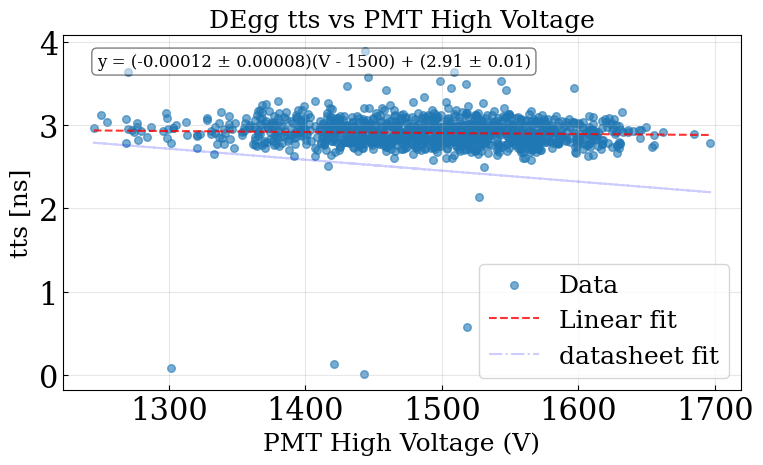

In [158]:
from scipy.optimize import curve_fit
import numpy as np

# Define linear function
def linear(x, m, b):
    return m * (x-1500) + b

# Fit the data
popt, pcov = curve_fit(linear, hv_list, sigma_list)
m, b = popt
m_err, b_err = np.sqrt(np.diag(pcov))

# Create plot with fit
fig = plt.figure(figsize=(8,5))
gs = gridspec.GridSpec(nrows=1,ncols=1)
ax = fig.add_subplot(gs[0])

ax.scatter(hv_list, sigma_list, alpha=0.6, s=30, label='Data')

# Plot fit line
x_fit = np.linspace(min(hv_list), max(hv_list), 100)
y_fit = linear(x_fit, m, b)
sigma_list_equation = [get_tts(hv) for hv in hv_list]
ax.plot(x_fit, y_fit, color='red', linestyle='--', alpha=0.8, label='Linear fit')
ax.plot(hv_list, sigma_list_equation, color='blue', linestyle='-.', alpha=0.2, label='datasheet fit')

# Add fit equation and errors to plot
equation_text = f'y = ({m:.5f} ± {m_err:.5f})(V - 1500) + ({b:.2f} ± {b_err:.2f})'
ax.text(0.05, 0.95, equation_text, transform=ax.transAxes, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5),
        fontsize=12)

ax.set_xlabel('PMT High Voltage (V)')
ax.set_ylabel('tts [ns]', fontsize=18)
ax.set_title('DEgg tts vs PMT High Voltage', fontsize=18)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax.tick_params(axis='both', which='both', direction='in', labelsize=22)
ax.legend()

plt.tight_layout()
plt.savefig(f'{plotFolder}/degg_tts_vs_hv_fit_1500.png', dpi=300)
plt.show()

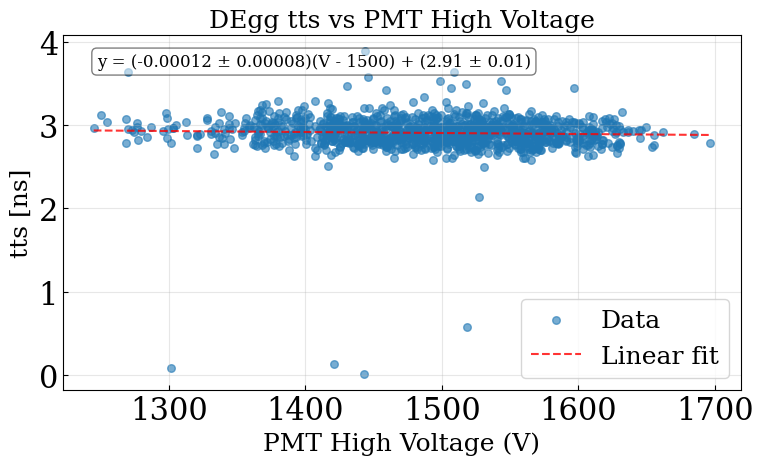

In [159]:
# Create plot with fit
fig = plt.figure(figsize=(8,5))
gs = gridspec.GridSpec(nrows=1,ncols=1)
ax = fig.add_subplot(gs[0])

ax.scatter(hv_list, sigma_list, alpha=0.6, s=30, label='Data')

# Plot fit line
x_fit = np.linspace(min(hv_list), max(hv_list), 100)
y_fit = linear(x_fit, m, b)
sigma_list_equation = [get_tts(hv) for hv in hv_list]
ax.plot(x_fit, y_fit, color='red', linestyle='--', alpha=0.8, label='Linear fit')
# ax.plot(hv_list, sigma_list_equation, color='blue', linestyle='-.', alpha=0.2, label='datasheet fit')

# Add fit equation and errors to plot
equation_text = f'y = ({m:.5f} ± {m_err:.5f})(V - 1500) + ({b:.2f} ± {b_err:.2f})'
ax.text(0.05, 0.95, equation_text, transform=ax.transAxes, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5),
        fontsize=12)

ax.set_xlabel('PMT High Voltage (V)')
ax.set_ylabel('tts [ns]', fontsize=18)
ax.set_title('DEgg tts vs PMT High Voltage', fontsize=18)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax.tick_params(axis='both', which='both', direction='in', labelsize=22)
ax.legend()

plt.tight_layout()
plt.savefig(f'{plotFolder}/degg_tts_vs_hv_fit_1500_.png', dpi=300)
plt.show()

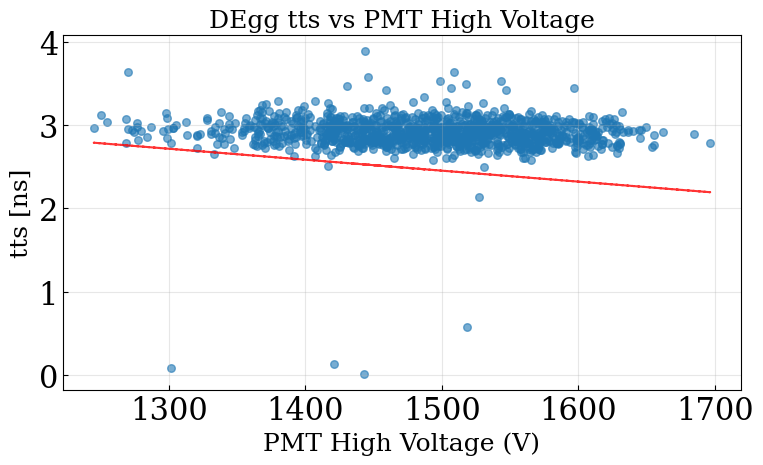

In [151]:
fig = plt.figure(figsize=(8,5))
gs = gridspec.GridSpec(nrows=1,ncols=1)
ax = fig.add_subplot(gs[0])
sigma_list_equation = [get_tts(hv) for hv in hv_list]
ax.scatter(hv_list, sigma_list, alpha=0.6, s=30)
ax.plot(hv_list, sigma_list_equation, color='red', linestyle='--', alpha=0.8)
ax.set_xlabel('PMT High Voltage (V)')
ax.set_ylabel('tts [ns]',fontsize=18)
ax.set_title('DEgg tts vs PMT High Voltage',fontsize=18)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax.tick_params(axis='both',which='both', direction='in', labelsize=22)
plt.tight_layout()
plt.savefig(f'{plotFolder}/sigma_vs_hv.png', dpi=300)
plt.show()

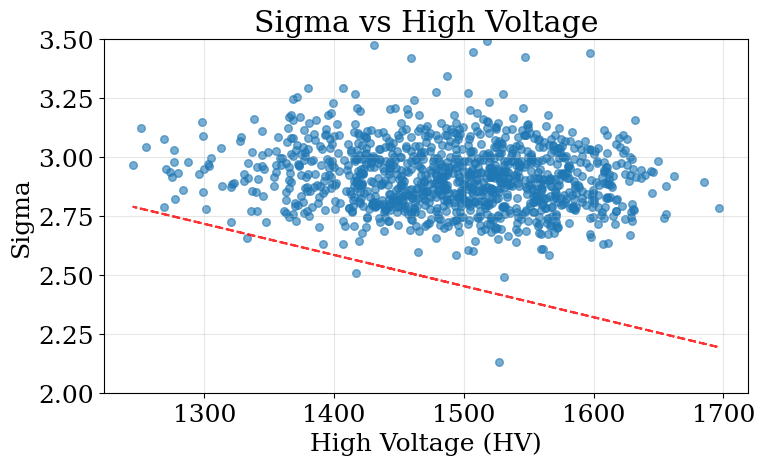

In [152]:
fig = plt.figure(figsize=(8,5))
gs = gridspec.GridSpec(nrows=1,ncols=1)
ax = fig.add_subplot(gs[0])
sigma_list_equation = [get_tts(hv) for hv in hv_list]
ax.scatter(hv_list, sigma_list, alpha=0.6, s=30)
ax.plot(hv_list, sigma_list_equation, color='red', linestyle='--', alpha=0.8)
ax.set_xlabel('High Voltage (HV)')
ax.set_ylabel('Sigma')
ax.set_title('Sigma vs High Voltage')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax.set_ylim(2, 3.5)
plt.tight_layout()
plt.savefig(f'{plotFolder}/sigma_vs_hv.png', dpi=300)
plt.show()